C:\Users\Anton Torejev\Documents\SV Data
T= 5285 mean= -3.676235180878002e-20 std= 0.012029020001935177


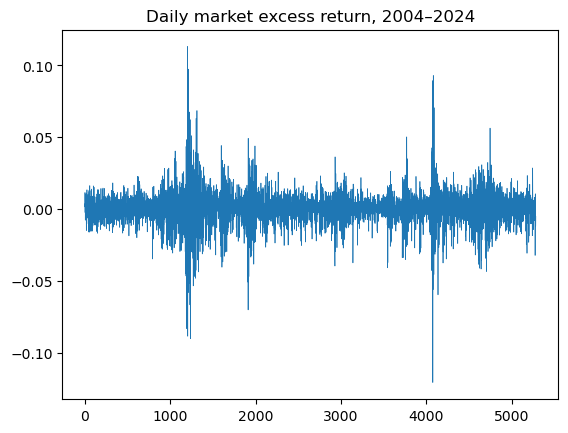

mu:    -9.098343505267856
phi:   0.9654482824545889
sigma: 0.15789539356497548


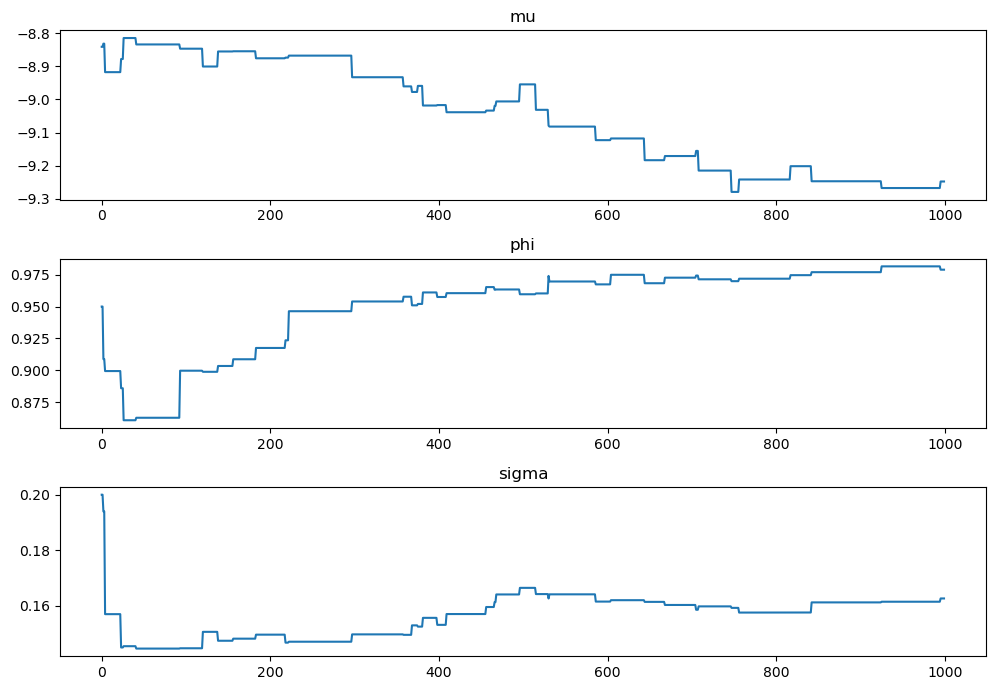

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs(r'C:\Users\Anton Torejev\Documents\SV Data', exist_ok=True) 
os.chdir(r'C:\Users\Anton Torejev\Documents\SV Data')                     
print(os.getcwd())
ff = pd.read_csv('F-F_Research_Data_Factors_daily.CSV', skiprows = 3)
ff = ff.rename(columns={'Unnamed: 0': 'Date'})
ff = ff[ff['Date'].astype(str).str.match(r'^\d{8}$')]      
ff['Date'] = pd.to_datetime(ff['Date'], format='%Y%m%d')   
ff = ff.set_index('Date')
ff[['Mkt-RF','SMB','HML','RF']] = ff[['Mkt-RF','SMB','HML','RF']].astype(float) / 100
sub = ff.loc['2004-01-01':'2024-12-31']
r = sub['Mkt-RF'].values
r=r-r.mean()
T = len(r)
print("T=",T,"mean=",r.mean(), "std=", r.std())
plt.plot(figsize=(12,4))
plt.plot(r,lw=0.5)
plt.title("Daily market excess return, 2004–2024")
plt.show()

mu_init    = np.log(r.var())  
phi_init   = 0.95              
sigma_init = 0.2 
T = len(r)
h=np.zeros(T)

def log_target(h, mu, phi, sigma):
    if abs(phi) >= 1 or sigma <= 0:
        return -np.inf
    prediction = mu + phi*(h[:-1] - mu)
    error = h[1:] - prediction
    ar_1     = -(T-1)*np.log(sigma) - 0.5*np.sum(error**2 / sigma**2)
    obs_term = -0.5*np.sum(h) - 0.5*np.sum(r**2 / np.exp(h))
    return ar_1 + obs_term

def local_log_h(h, t, mu, phi, sigma):
    val = -0.5*h[t] - 0.5*r[t]**2 / np.exp(h[t])
    if t > 0:
        val += -(h[t] - mu - phi*(h[t-1]-mu))**2 / (2*sigma**2)
    if t < T-1:
        val += -(h[t+1] - mu - phi*(h[t]-mu))**2 / (2*sigma**2)
    return val

def update_h_t(h, t, mu, phi, sigma, proposal_sd=0.2):
    old_val   = h[t]
    old_score = local_log_h(h, t, mu, phi, sigma)
    h[t]      = old_val + np.random.normal(0, proposal_sd)  
    new_score = local_log_h(h, t, mu, phi, sigma)  
    if np.log(np.random.uniform()) < new_score - old_score:
        return h                   
    else:
        h[t] = old_val             
        return h

def metropolis(h, mu, phi, sigma, std_mu=0.05, std_phi=0.02, std_sigma=0.02):
    mu_prop    = mu    + np.random.normal(0, std_mu)
    phi_prop   = phi   + np.random.normal(0, std_phi)
    sigma_prop = sigma + np.random.normal(0, std_sigma)

    log_alpha = log_target(h, mu_prop, phi_prop, sigma_prop) \
              - log_target(h, mu, phi, sigma)

    if np.log(np.random.uniform()) < log_alpha:
        return mu_prop, phi_prop, sigma_prop
    else:
        return mu, phi, sigma

def run_mcmc(n_samples, mu_init, phi_init, sigma_init, proposal_sd=0.2):
    h=np.full(T, mu_init)
    mu, phi, sigma = mu_init, phi_init, sigma_init
    chain_h      = np.zeros((n_samples, T))
    chain_params = np.zeros((n_samples, 3))

    for s in range(n_samples):
        for t in range(T):
            h = update_h_t(h, t, mu, phi, sigma, proposal_sd=proposal_sd)
        mu, phi, sigma = metropolis(h, mu, phi, sigma)

        chain_h[s] = h
        chain_params[s] = [mu, phi, sigma]
    return chain_params, chain_h

chain_params, chain_h = run_mcmc(1000, mu_init=np.log(r.var()), phi_init=0.95, sigma_init=0.2)
burn = 200
print("mu:   ", chain_params[burn:,0].mean())
print("phi:  ", chain_params[burn:,1].mean())
print("sigma:", chain_params[burn:,2].mean())

fig, ax = plt.subplots(3, 1, figsize=(10, 7))
ax[0].plot(chain_params[:,0]); ax[0].set_title("mu")
ax[1].plot(chain_params[:,1]); ax[1].set_title("phi")
ax[2].plot(chain_params[:,2]); ax[2].set_title("sigma")
plt.tight_layout(); plt.show()

h_est = chain_h[200:].mean(axis=0)      
vol = np.exp(h_est/2)                     

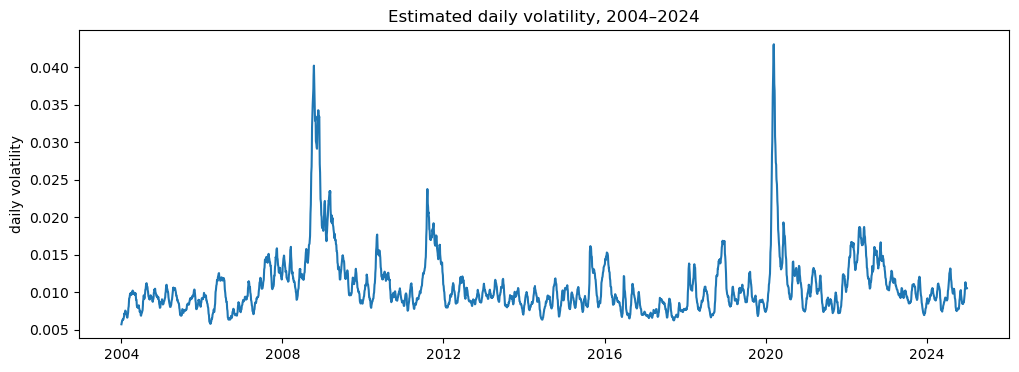

In [4]:
h_est = chain_h[200:].mean(axis=0)    
vol = np.exp(h_est/2)                    

plt.figure(figsize=(12,4))
plt.plot(sub.index, vol)
plt.title("Estimated daily volatility, 2004–2024")
plt.ylabel("daily volatility")
plt.show()

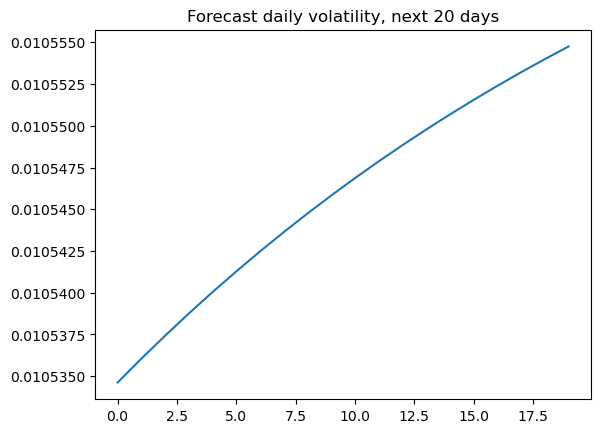

In [5]:
h_T = h_est[-1]                         
mu, phi = chain_params[200:,0].mean(), chain_params[200:,1].mean()

forecast = [mu + phi**k * (h_T - mu) for k in range(1, 21)]
vol_forecast = np.exp(np.array(forecast)/2)   

plt.plot(vol_forecast)
plt.title("Forecast daily volatility, next 20 days")
plt.show()